# Supplementary Fig. 25 — LRR and BAF deviations for mCA detection (simulated schematic)

**Simulated schematic** showing how mosaic chromosomal alterations (mCAs) of different cell fractions affect
B-allele frequency (**BAF**, top row of each panel) and log2R ratio (**LRR / log2ratio**, bottom row). Each SNP
is homozygous AA (BAF 0), heterozygous AB (BAF ~0.5) or homozygous BB (BAF 1). For a heterozygous SNP the BAF
splits by a deviation that grows with cell fraction *f*, per the event formulae (Table S5):

| event | BAF deviation from 0.5 | LRR |
|---|---|---|
| **gain** (red)   | f / (2·(2+f)) | log₂((2+f)/2) |
| **loss** (blue)  | f / (2·(2−f)) | log₂((2−f)/2) |
| **CN-LOH** (orange) | f / 2      | 0 |
| **normal** (black)  | 0          | 0 |

At 100% cell fraction both loss and CN-LOH give complete loss of heterozygosity (BAF → 0/1). Simulated with
100 SNPs per region and mean read depth 1000; the value next to each cluster is the simulated mean BAF (top) /
LRR (bottom). 

## Data availability
Self-contained **simulated** schematic — no measured or individual-level data. Uses the custom matplotlib
style `cwpython.mplstyle`.

## 1. Imports, custom style, colours

In [1]:
# import packages
import random
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.style.use('Data_files/cwpython.mplstyle') #use custom style file

In [3]:
# Lists of colors for plots
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33);
c2 = (1.00, 0.23, 0.19);
c3 = (1.00, 0.58, 0.00);
c4 = (1.00, 0.80, 0.00);
c5 = (0.30, 0.85, 0.39);
c6 = (0.35, 0.78, 0.98);
c7 = (0.20, 0.67, 0.86);
c8 = (0.00, 0.48, 1.00);
c9 = (0.35, 0.34, 0.84);
c10 = (0.00, 0.31, 0.57);
c11 = (0.12, 0.29, 0.69);
c12 = (0.17, 0.17, 0.42);
c13 = (1.00, 1.00, 1.00);
c14 = (0.77, 0.04, 0.00);

In [4]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'
yellow = '#ffffd4'

In [5]:
# seed the simulation so the illustrative scatter is reproducible on re-run
# (the labelled mean BAF / LRR values are deterministic from the event formulae regardless)
import random, numpy as np
random.seed(0)
np.random.seed(0)

## 2. Simulation and plotting functions

In [6]:
mean_read_depth = 900

In [7]:
def SNPs_LRR_list(mCA, cell_fraction, number_SNPs, mean_read_depth):
    
    SNPs_list = []
    LRR_list = []
    averages = []
    
    for i in range(number_SNPs):
        SNP_type = [0, 0.5, 1.0]
        hetero_homo = random.choice(SNP_type)

        if hetero_homo == 0:
            VAF = 0

        if hetero_homo == 1:
            VAF = 1

        if hetero_homo == 0.5: #heterozygous SNP
            if mCA == 'loss':
                BAF_deviation = (cell_fraction/(2*(2-cell_fraction)))
            if mCA == 'gain':
                BAF_deviation = (cell_fraction/(2*(2+cell_fraction)))
            if mCA == 'CN-LOH':
                BAF_deviation = cell_fraction/2
            if mCA == 'normal':
                BAF_deviation = 0

            phasing = random.choice(['-', '+'])
            if phasing == '+':
                BAF = 0.5+BAF_deviation
            if phasing == '-':
                BAF = 0.5-BAF_deviation
            VAF = (np.random.binomial(mean_read_depth, BAF, 1)[0])/mean_read_depth
            
            averages = (0.5+BAF_deviation, 0.5-BAF_deviation)
            
        SNPs_list.append(VAF)
        
        if mCA == 'loss':
            LRR_list.append(np.log2((2-cell_fraction)/2))
        if mCA == 'gain':
            LRR_list.append(np.log2((2+cell_fraction)/2))
        if mCA == 'CN-LOH':
            LRR_list.append(0)
        if mCA == 'normal':
            LRR_list.append(0)
        
    return (SNPs_list, LRR_list, averages)

In [8]:
def SNPs_plot(mCA_type, cell_fraction, number_SNPs, mean_read_depth, ax):
    m_size = 100
    axisfont=15
    titlefont=15
    axislabelfont=15
    exonfont=12
    
    SNPs, LRR, average_BAF = SNPs_LRR_list(mCA_type, cell_fraction, number_SNPs, mean_read_depth)

    #SNPs
    x1 = []
    y1 = []
    counter = 1
    for i in SNPs:
        x1.append(counter)
        y1.append(i)
        counter+=1
        
    if mCA_type == 'gain':
        color = red4
    if mCA_type == 'loss':
        color = blue4
    if mCA_type == 'CN-LOH':
        color = orange3
    if mCA_type == 'normal':
        color = grey5

    ax.scatter(x1, y1, color = color, zorder = 200, lw = 1)
#     ax.plot([0, number_SNPs], [average_BAF[0], average_BAF[0]], color = color, alpha = 0.2, zorder = 5, lw = 3)
#     ax.plot([0, number_SNPs], [average_BAF[1], average_BAF[1]], color = color, alpha = 0.2, zorder = 5, lw = 3)

    upper_BAF = round(average_BAF[0], 4)
    lower_BAF = round(average_BAF[1], 4)
    
    if upper_BAF<0.7:
        ax.text(0.99, lower_BAF-0.05, str(lower_BAF), transform=ax.transAxes, ha = 'right', va = 'top', fontsize = 13, zorder = 1000)
        ax.text(0.99, upper_BAF+0.05, str(upper_BAF), transform=ax.transAxes, ha = 'right', fontsize = 13, zorder = 1000)
    else:
        ax.text(0.99, lower_BAF+0.05, str(lower_BAF), transform=ax.transAxes, ha = 'right', va = 'bottom', fontsize = 13, zorder = 1000)
        ax.text(0.99, upper_BAF-0.05, str(upper_BAF), transform=ax.transAxes, ha = 'right', va = 'top', fontsize = 13, zorder = 1000)

    # CONFIGURING THE GRAPH APPEARANCE
    ax.set_xlim(0, number_SNPs)

    #x-axis ticks
    x1_major_ticks = []
    x1_major_tick_labels = []
    ax.set_xticks(x1_major_ticks)
    ax.set_xticklabels(x1_major_tick_labels, fontsize = axisfont)

    #y-axis ticks
    y1_major_ticks = []
    y1_major_tick_labels = []
    ax.set_xticks(y1_major_ticks)
    ax.set_xticklabels(y1_major_tick_labels, fontsize = axisfont)
#     ax.tick_params(axis='y', which='major', labelsize=13)

    #Only show the required axis lines
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

#     ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    ax.set_ylim(-0.02, 1.02)

    #Title and axis labels
    ax.set_title(str(int(cell_fraction*100))+'% '+mCA_type, fontweight = 'medium', fontsize = 15, y = 1.05)
    if mCA_type == 'normal':
        ax.set_title('normal', fontweight = 'medium', fontsize = 15, y = 1.05)
#     ax.set_ylabel('BAF', fontsize = axislabelfont)

    return ax

In [9]:
def LRR_plot(mCA_type, cell_fraction, number_SNPs, mean_read_depth, ax):
    m_size = 100
    axisfont=15
    titlefont=15
    axislabelfont=15
    exonfont=12
    
    SNPs, LRR, average_BAF = SNPs_LRR_list(mCA_type, cell_fraction, number_SNPs, mean_read_depth)

    #LRR
    x1 = []
    y1 = []
    counter = 1
    for i in LRR:
        x1.append(counter)
        y1.append(i)
        counter+=1
        
    if mCA_type == 'gain':
        color = red4
    if mCA_type == 'loss':
        color = blue4
    if mCA_type == 'CN-LOH':
        color = orange3
    if mCA_type == 'normal':
        color = grey5

    ax.plot(x1, y1, color = color, zorder = 200, lw = 3)
    
    LRR = y1[0]
    
    ax.text(number_SNPs, LRR+0.075, str(round(LRR, 2)), ha = 'right', fontsize = 13, zorder = 1000)

    # CONFIGURING THE GRAPH APPEARANCE
    ax.set_xlim(0, number_SNPs)

    # Changing the y axis to log scale
    ax.set_ylim(-1.1, 1.)

    #x-axis ticks
    x1_major_ticks = []
    x1_major_tick_labels = []
    ax.set_xticks(x1_major_ticks)
    ax.set_xticklabels(x1_major_tick_labels, fontsize = axisfont)

    #y-axis ticks
    y1_major_ticks = []
    y1_major_tick_labels = []
    ax.set_xticks(y1_major_ticks)
    ax.set_xticklabels(y1_major_tick_labels, fontsize = axisfont)
#     ax.tick_params(axis='y', which='major', labelsize=13)

    #Only show the required axis lines
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    #Title and axis labels
#     ax.set_title(mCA_type+': '+str(int(cell_fraction*100))+'% cell fraction')
#     ax.set_ylabel('log2ratio', fontsize = axislabelfont)
    
    return ax

In [10]:
def mCA_plots_different_cell_fractions(mCA_type, mean_read_depth, number_SNPs):
    plt.close('all')
    f, (axes) = plt.subplots(2, 8, sharey=False, sharex = False, figsize=(20, 6), gridspec_kw={'height_ratios': [3, 3]})
    # gs = matplotlib.gridspec.GridSpec(2, 8, height_ratios=[3,1])

    ax1 = axes[0, 0]
    ax2 = axes[0, 1]
    ax3 = axes[0, 2]
    ax4 = axes[0, 3]
    ax5 = axes[0, 4]
    ax6 = axes[0, 5]
    ax7 = axes[0, 6]
    ax8 = axes[0, 7]
    ax9 = axes[1, 0]
    ax10 = axes[1, 1]
    ax11 = axes[1, 2]
    ax12 = axes[1, 3]
    ax13 = axes[1, 4]
    ax14 = axes[1, 5]
    ax15 = axes[1, 6]
    ax16 = axes[1, 7]

    m_size = 100
    axisfont=13
    titlefont=15
    axislabelfont=15
    exonfont=12

    SNPs_plot('normal', 1, number_SNPs, mean_read_depth, ax1)
    SNPs_plot(mCA_type, 0.05, number_SNPs, mean_read_depth, ax2)
    SNPs_plot(mCA_type, 0.1, number_SNPs, mean_read_depth, ax3)
    SNPs_plot(mCA_type, 0.25, number_SNPs, mean_read_depth, ax4)
    SNPs_plot(mCA_type, 0.5, number_SNPs, mean_read_depth, ax5)
    SNPs_plot(mCA_type, 0.75, number_SNPs, mean_read_depth, ax6)
    SNPs_plot(mCA_type, 0.9, number_SNPs, mean_read_depth, ax7)
    SNPs_plot(mCA_type, 1.0, number_SNPs, mean_read_depth, ax8)

    LRR_plot('normal', 1, number_SNPs, mean_read_depth, ax9)
    LRR_plot(mCA_type, 0.05, number_SNPs, mean_read_depth, ax10)
    LRR_plot(mCA_type, 0.1, number_SNPs, mean_read_depth, ax11)
    LRR_plot(mCA_type, 0.25, number_SNPs, mean_read_depth, ax12)
    LRR_plot(mCA_type, 0.5, number_SNPs, mean_read_depth, ax13)
    LRR_plot(mCA_type, 0.75, number_SNPs, mean_read_depth, ax14)
    LRR_plot(mCA_type, 0.9, number_SNPs, mean_read_depth, ax15)
    LRR_plot(mCA_type, 1.0, number_SNPs, mean_read_depth, ax16)

    y1_major_ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    y1_major_tick_labels = ['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']
    ax1.set_yticks(y1_major_ticks)
    ax1.set_yticklabels(y1_major_tick_labels, fontsize = axisfont)
    ax1.set_ylabel('BAF')
    ax1.spines['left'].set_visible(True)
    
    for ax in [ax2, ax3, ax4, ax5, ax6, ax7]:
        y1_major_ticks = []
        y1_major_tick_labels = []
        ax.set_yticks(y1_major_ticks)
        ax.set_yticklabels(y1_major_tick_labels, fontsize = axisfont)
        
    y1_major_ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    y1_major_tick_labels = ['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']
    ax8.set_yticks(y1_major_ticks)
    ax8.set_yticklabels(y1_major_tick_labels, fontsize = axisfont)
    ax8.set_ylabel('BAF')
    ax8.yaxis.tick_right()
    ax8.yaxis.set_label_position("right")
    ax8.spines['right'].set_visible(True)
        
    y1_major_ticks = [-1.0, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    y1_major_tick_labels = ['-1.0', '-0.8', '-0.6', '-0.4', '-0.2', '0.0', '0.2', '0.4', '0.6', '0.8', '1.0']
    ax9.set_yticks(y1_major_ticks)
    ax9.set_yticklabels(y1_major_tick_labels, fontsize = axisfont)
    ax9.set_ylabel('log2ratio')
    
    for ax in [ax10, ax11, ax12, ax13, ax14, ax15]:
        y1_major_ticks = []
        y1_major_tick_labels = []
        ax.set_yticks(y1_major_ticks)
        ax.set_yticklabels(y1_major_tick_labels, fontsize = axisfont)
        
    y1_major_ticks = [-1.0, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    y1_major_tick_labels = ['-1.0', '-0.8', '-0.6', '-0.4', '-0.2', '0.0', '0.2', '0.4', '0.6', '0.8', '1.0']
    ax16.set_yticks(y1_major_ticks)
    ax16.set_yticklabels(y1_major_tick_labels, fontsize = axisfont)
    ax16.set_ylabel('log2ratio')
    ax16.yaxis.tick_right()
    ax16.yaxis.set_label_position("right")
    ax16.spines['right'].set_visible(True)
    
    
    for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]:
        ax.plot([0, number_SNPs], [0.1, 0.1], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.2, 0.2], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.3, 0.3], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.4, 0.4], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.5, 0.5], lw = 4, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.6, 0.6], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.7, 0.7], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.8, 0.8], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.9, 0.9], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [1.0, 1.0], lw = 2, color = grey2, linestyle = ':')

    for ax in [ax9, ax10, ax11, ax12, ax13, ax14, ax15, ax16]:
        ax.plot([0, number_SNPs], [-0.2, -0.2], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [-0.4, -0.4], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [-0.6, -0.6], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [-0.8, -0.8], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [-1.0, -1.0], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0, 0], lw = 4, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.2, 0.2], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.4, 0.4], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.6, 0.6], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [0.8, 0.8], lw = 2, color = grey2, linestyle = ':')
        ax.plot([0, number_SNPs], [1.0, 1.0], lw = 2, color = grey2, linestyle = ':')

    plt.tight_layout()
    return plt.show()

## 3. Gain events (BAF top, log2ratio bottom)

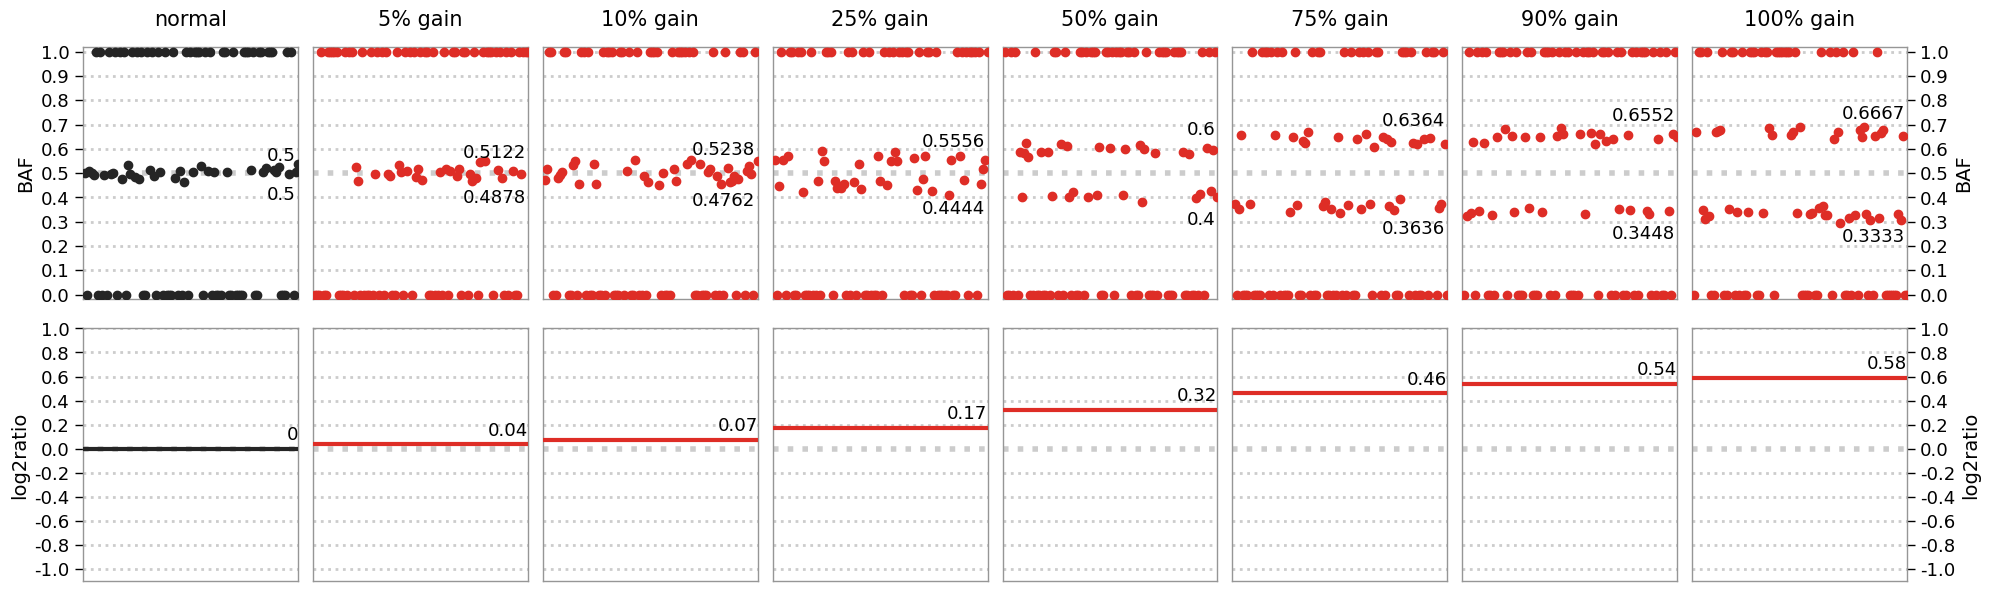

In [11]:
mCA_plots_different_cell_fractions('gain', 1000, 100)

## 4. Loss events

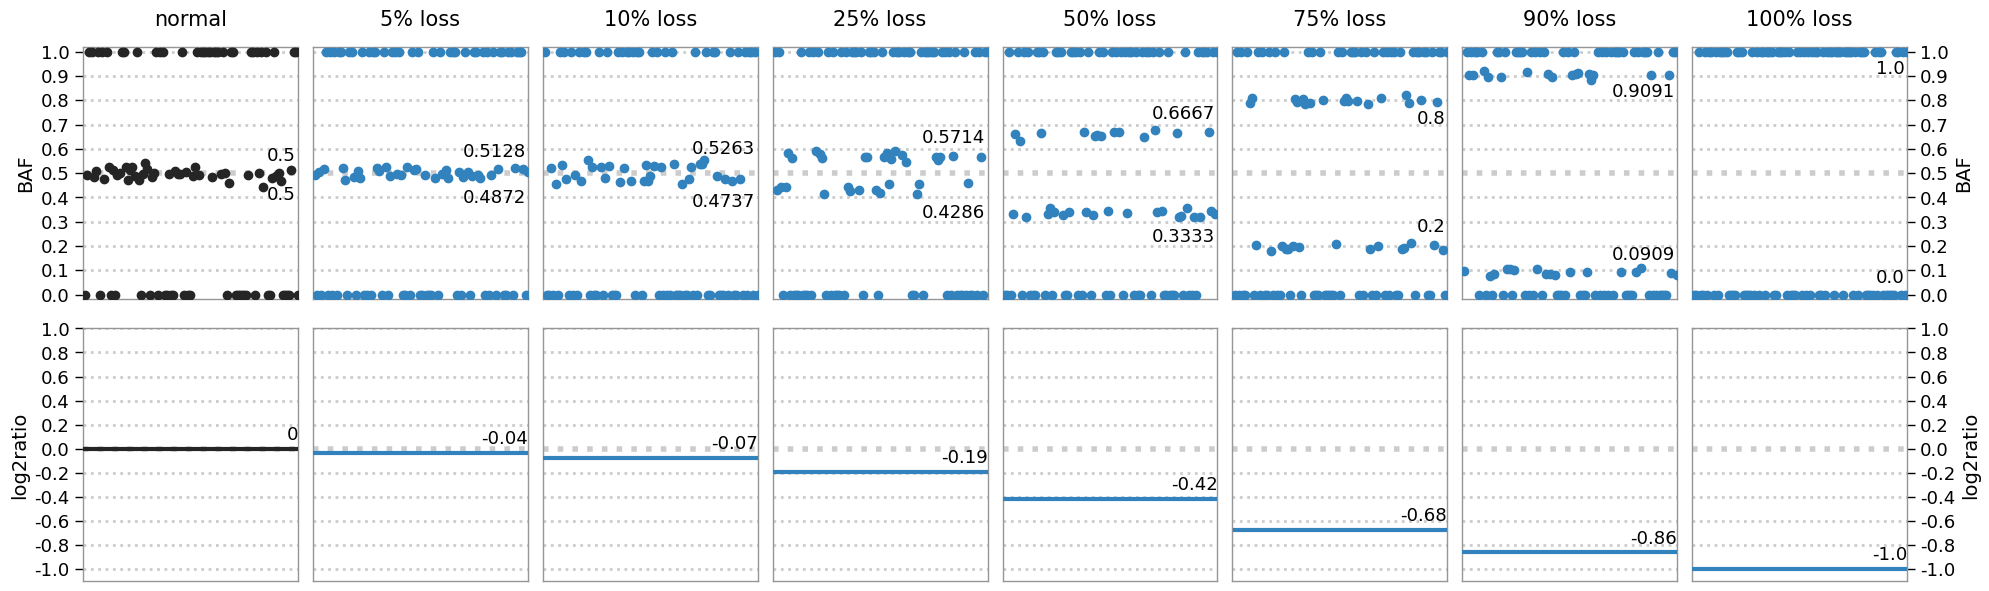

In [12]:
mCA_plots_different_cell_fractions('loss', 1000, 100)

## 5. CN-LOH events

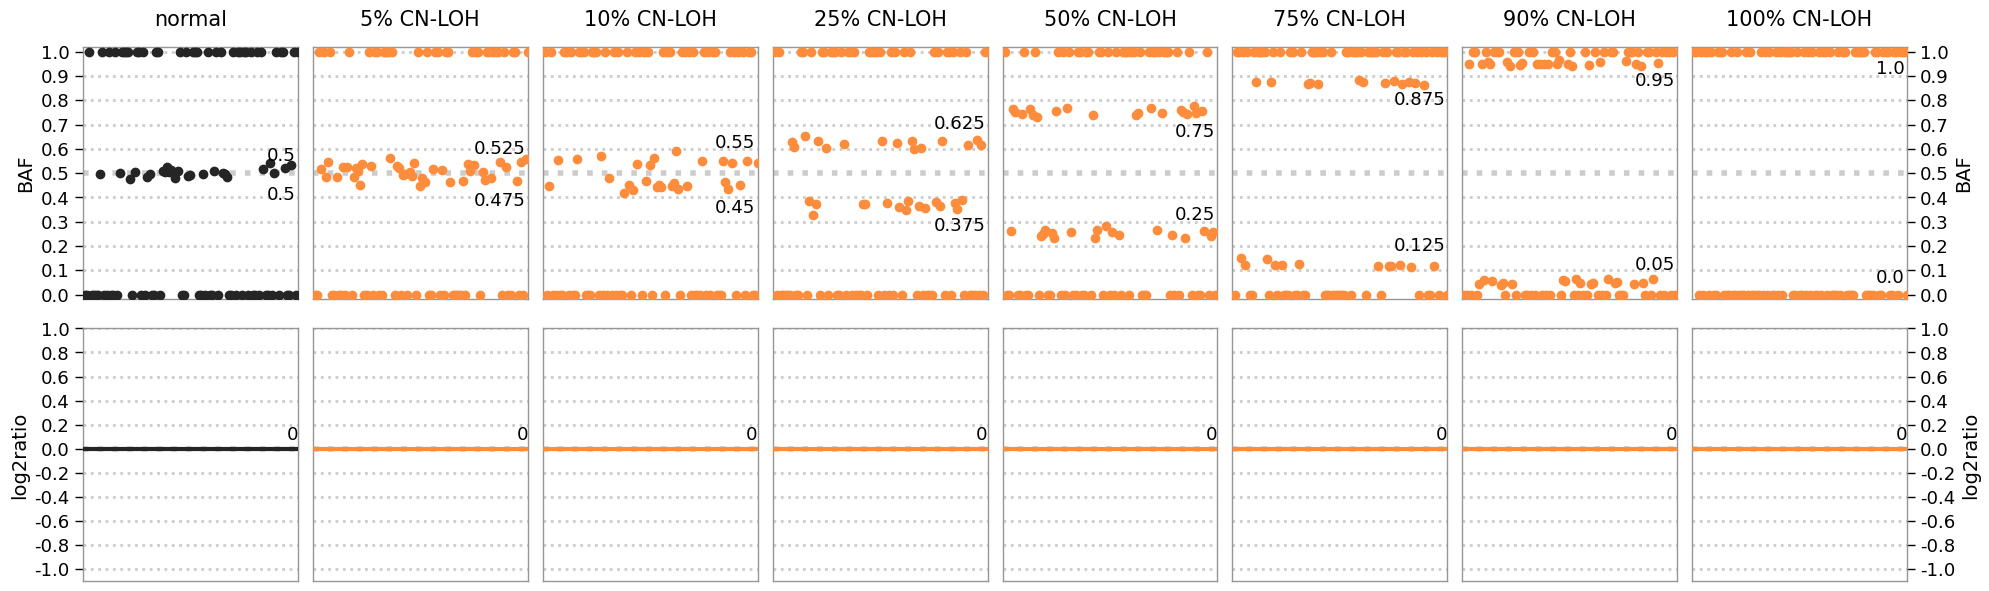

In [13]:
mCA_plots_different_cell_fractions('CN-LOH', 1000, 100)